# MLflow: отслеживание экспериментов для ML моделей

**Цель:** Сравнить различные ML модели с отслеживанием экспериментов через MLflow

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Подавление предупреждений 
import warnings
warnings.filterwarnings('ignore')

# Настройка MLflow с SQLite
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Сравнение ML Классификации")

print(f"MLflow URI: {mlflow.get_tracking_uri()}")
print(f"Эксперимент: {mlflow.get_experiment_by_name('Сравнение ML Классификации').name}")

MLflow URI: sqlite:///mlflow.db
Эксперимент: Сравнение ML Классификации


In [26]:
df = pd.read_csv('synthetic_classification_dataset.csv')
print(f"Размер датасета: {df.shape}")
print("\nПервые 3 строки:")
print(df.head(3))

Размер датасета: (400, 7)

Первые 3 строки:
   income_level  age_group  credit_score_derived  debt_ratio_derived  \
0  43300.732291  21.822748            632.536795            0.192779   
1  45798.087077  23.665852            623.884006            0.236328   
2  53405.707304  28.277690            596.823548            0.335761   

   zip_code  phone_area_code  target  
0     77841              489       1  
1     42134              787       1  
2     84522              895       2  


In [27]:
print("ОБЗОР ДАННЫХ")
print(f"Пропуски: {df.isnull().sum().sum()}")
print(f"Количество классов: {df['target'].nunique()}")
print(f"Распределение классов: {df['target'].value_counts().to_dict()}")
print("\nОписательная статистика:")
print(df.describe().round(2))

ОБЗОР ДАННЫХ
Пропуски: 0
Количество классов: 3
Распределение классов: {2: 135, 1: 134, 0: 131}

Описательная статистика:
       income_level  age_group  credit_score_derived  debt_ratio_derived  \
count        400.00     400.00                400.00              400.00   
mean       51966.35      28.16                599.22                0.35   
std         7345.48      11.49                 33.81                0.30   
min        25473.08      -2.34                465.44               -0.43   
25%        48644.12      21.42                587.91                0.17   
50%        53967.78      25.64                602.35                0.29   
75%        56476.13      31.80                618.30                0.45   
max        67872.10      78.12                673.61                1.62   

       zip_code  phone_area_code  target  
count    400.00           400.00  400.00  
mean   54826.46           594.63    1.01  
std    25366.75           235.55    0.82  
min    10028.00       

КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
debt_ratio_derived: -0.450
age_group: -0.448
credit_score_derived: 0.337
zip_code: -0.037
phone_area_code: -0.026
income_level: -0.023


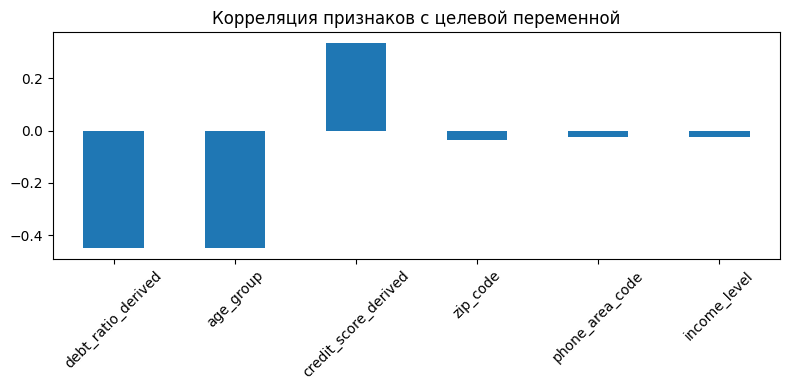

In [28]:
# Корреляция с целевой переменной — быстрый расчёт
print("КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
correlations = df.drop('target', axis=1).corrwith(df['target']).sort_values(key=abs, ascending=False)
for feature, corr in correlations.items():
    print(f"{feature}: {corr:.3f}")

# Визуализация — эффективная
plt.figure(figsize=(8, 4))
correlations.plot(kind='bar')
plt.title('Корреляция признаков с целевой переменной')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# Подготовка данных — оптимальная
X = df.drop('target', axis=1)
y = df['target']

# Разделение — стратифицированное для баланса
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабирование — только для нужных моделей
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape}, Тестовая: {X_test.shape}")
print(f"Классы (обучение): {y_train.value_counts().to_dict()}")
print(f"Классы (тест): {y_test.value_counts().to_dict()}")

Обучающая выборка: (320, 6), Тестовая: (80, 6)
Классы (обучение): {2: 108, 1: 107, 0: 105}
Классы (тест): {2: 27, 1: 27, 0: 26}


In [30]:
# Анализ масштабов признаков — быстрый
print("АНАЛИЗ МАСШТАБОВ ПРИЗНАКОВ")
feature_stats = df.drop('target', axis=1).describe().transpose()

max_mean = feature_stats['mean'].max()
min_mean = feature_stats['mean'].min()
scale_diff = (max_mean - min_mean) / min_mean * 100

print(f"Макс. среднее: {max_mean:.2f}")
print(f"Мин. среднее: {min_mean:.2f}")
print(f"Различие масштабов: {scale_diff:.1f}%")

if scale_diff > 50:
    print("МАСШТАБИРОВАНИЕ ОБЯЗАТЕЛЬНО")
else:
    print("Масштабирование не требуется")

# Эффективная функция для обучения и логирования
def train_and_evaluate_mlflow(model, X_train, X_test, y_train, y_test, model_name, use_scaled=False):
    """Обучает модель и логирует в MLflow — оптимизированно"""
    
    # Выбор данных
    train_data = X_train_scaled if use_scaled else X_train
    test_data = X_test_scaled if use_scaled else X_test
    
    with mlflow.start_run(run_name=model_name) as run:
        # Логирование параметров
        mlflow.log_param("тип_модели", model_name)
        mlflow.log_param("масштабирование", use_scaled)
        mlflow.log_param("размер_обучения", len(X_train))
        mlflow.log_param("размер_теста", len(X_test))
        mlflow.log_param("кол_признаков", X_train.shape[1])
        mlflow.log_param("кол_классов", len(np.unique(y_train)))
        
        # Логирование гиперпараметров — только важные
        if hasattr(model, 'get_params'):
            params = model.get_params()
            for param_name, param_value in params.items():
                if param_value is not None and isinstance(param_value, (int, float, str, bool)):
                    if param_name in ['random_state', 'n_neighbors', 'max_depth', 'max_iter']:
                        mlflow.log_param(f"модель_{param_name}", param_value)
        
        # Обучение
        model.fit(train_data, y_train)
        
        # Предсказания
        y_train_pred = model.predict(train_data)
        y_test_pred = model.predict(test_data)
        
        # Метрики — быстрый расчёт
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        test_f1 = f1_score(y_test, y_test_pred, average='weighted')
        overfitting = train_acc - test_acc
        
        # Логирование метрик
        mlflow.log_metric("точность_обучения", train_acc)
        mlflow.log_metric("точность_теста", test_acc)
        mlflow.log_metric("f1_теста", test_f1)
        mlflow.log_metric("переобучение", overfitting)
        
        # Логирование матрицы ошибок — оптимизированное
        cm = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Матрица ошибок — {model_name}')
        plt.ylabel('Истинные')
        plt.xlabel('Предсказанные')
        plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
        plt.close()
        mlflow.log_artifact('confusion_matrix.png')
        
        # Логирование модели
        signature = infer_signature(train_data, model.predict(train_data))
        mlflow.sklearn.log_model(model, "model", signature=signature)
        
        # Логирование информации о данных
        dataset_info = {
            'train_shape': train_data.shape,
            'test_shape': test_data.shape,
            'feature_names': list(X_train.columns)
        }
        mlflow.log_dict(dataset_info, "dataset_info.json")
        
        print(f"  Обучение: {train_acc:.3f}, Тест: {test_acc:.3f}, F1: {test_f1:.3f}")
        
        metrics = {
            'model': model_name,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'test_f1': test_f1,
            'overfitting': overfitting,
            'run_id': run.info.run_id
        }
        
        return metrics, model, run.info.run_id

АНАЛИЗ МАСШТАБОВ ПРИЗНАКОВ
Макс. среднее: 54826.46
Мин. среднее: 0.35
Различие масштабов: 15545484.3%
МАСШТАБИРОВАНИЕ ОБЯЗАТЕЛЬНО


In [31]:

results = []
models = {}
run_ids = {}

print("ОБУЧЕНИЕ МОДЕЛЕЙ С MLflow")

# Логистическая регрессия
print("\nЛогистическая регрессия...")
lr = LogisticRegression(random_state=42, max_iter=1000)
metrics, model, run_id = train_and_evaluate_mlflow(
    lr, X_train, X_test, y_train, y_test, "Логистическая Регрессия", use_scaled=True
)
results.append(metrics)
models['lr'] = model
run_ids['lr'] = run_id

# KNN
print("\nKNN...")
knn = KNeighborsClassifier(n_neighbors=5)
metrics, model, run_id = train_and_evaluate_mlflow(
    knn, X_train, X_test, y_train, y_test, "KNN", use_scaled=True
)
results.append(metrics)
models['knn'] = model
run_ids['knn'] = run_id

# SVM
print("\nSVM...")
svm = SVC(random_state=42, probability=True)
metrics, model, run_id = train_and_evaluate_mlflow(
    svm, X_train, X_test, y_train, y_test, "SVM", use_scaled=True
)
results.append(metrics)
models['svm'] = model
run_ids['svm'] = run_id

# Дерево решений
print("\nДерево решений...")
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
metrics, model, run_id = train_and_evaluate_mlflow(
    dt, X_train, X_test, y_train, y_test, "Дерево Решений", use_scaled=False
)
results.append(metrics)
models['dt'] = model
run_ids['dt'] = run_id

# Наивный Байес
print("\nНаивный Байес...")
nb = GaussianNB()
metrics, model, run_id = train_and_evaluate_mlflow(
    nb, X_train, X_test, y_train, y_test, "Наивный Байес", use_scaled=False
)
results.append(metrics)
models['nb'] = model
run_ids['nb'] = run_id

print("\nВсе модели обучены и залогированы в MLflow!")

ОБУЧЕНИЕ МОДЕЛЕЙ С MLflow

Логистическая регрессия...


2026/04/16 01:20:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 01:20:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Обучение: 0.731, Тест: 0.738, F1: 0.735

KNN...


2026/04/16 01:20:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 01:20:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Обучение: 0.828, Тест: 0.738, F1: 0.738

SVM...


...

  Обучение: 0.806, Тест: 0.725, F1: 0.717

Дерево решений...


2026/04/16 01:21:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 01:21:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Обучение: 0.900, Тест: 0.800, F1: 0.799

Наивный Байес...


2026/04/16 01:21:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 01:21:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Обучение: 0.772, Тест: 0.725, F1: 0.722

Все модели обучены и залогированы в MLflow!


СРАВНЕНИЕ МОДЕЛЕЙ
                  model  train_acc  test_acc  test_f1  overfitting
         Дерево Решений      0.900     0.800    0.799        0.100
                    KNN      0.828     0.738    0.738        0.091
Логистическая Регрессия      0.731     0.738    0.735       -0.006
          Наивный Байес      0.772     0.725    0.722        0.047
                    SVM      0.806     0.725    0.717        0.081


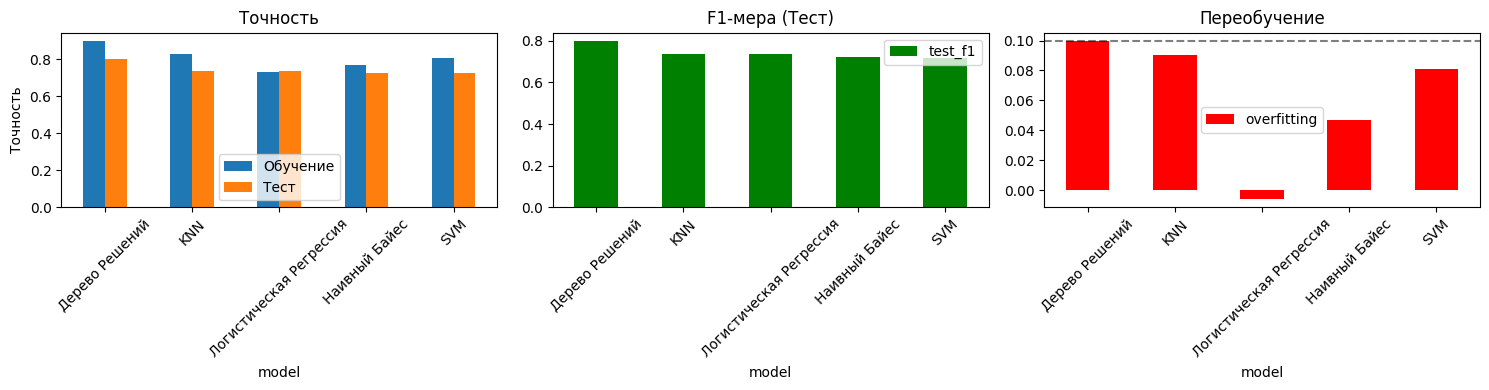

In [32]:
# Сравнение результатов — эффективно
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_f1', ascending=False)

print("СРАВНЕНИЕ МОДЕЛЕЙ")
display_df = results_df.drop('run_id', axis=1).round(3)
print(display_df.to_string(index=False))

# Визуализация — оптимальная
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Точность
results_df.plot(kind='bar', x='model', y=['train_acc', 'test_acc'], ax=axes[0])
axes[0].set_title('Точность')
axes[0].set_ylabel('Точность')
axes[0].legend(['Обучение', 'Тест'])
axes[0].tick_params(axis='x', rotation=45)

# F1-мера
results_df.plot(kind='bar', x='model', y='test_f1', ax=axes[1], color='green')
axes[1].set_title('F1-мера (Тест)')
axes[1].tick_params(axis='x', rotation=45)

# Переобучение
results_df.plot(kind='bar', x='model', y='overfitting', ax=axes[2], color='red')
axes[2].set_title('Переобучение')
axes[2].axhline(y=0.1, color='black', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Логирование сравнения в MLflow
with mlflow.start_run(run_name="Сравнение_Моделей") as run:
    mlflow.log_dict(display_df.to_dict(), "сравнение_моделей.json")
    
    # Создание графика сравнения
    plt.figure(figsize=(12, 6))
    results_df_melted = results_df.melt(id_vars=['model'], 
                                        value_vars=['train_acc', 'test_acc', 'test_f1'],
                                        var_name='метрика', value_name='значение')
    sns.barplot(data=results_df_melted, x='model', y='значение', hue='метрика')
    plt.title('Сравнение производительности моделей')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('сравнение_моделей.png', dpi=100, bbox_inches='tight')
    plt.close()
    mlflow.log_artifact('сравнение_моделей.png')

In [33]:
# Анализ переобучения
print("АНАЛИЗ ПЕРЕОБУЧЕНИЯ")
overfit_threshold = 0.1

overfitting = results_df[results_df['overfitting'] > overfit_threshold]
stable = results_df[results_df['overfitting'] <= overfit_threshold]

print(f"Модели с переобучением (> {overfit_threshold}):")
if len(overfitting) > 0:
    for _, row in overfitting.iterrows():
        print(f"  - {row['model']}: {row['overfitting']:.3f}")
else:
    print("  Нет")

print(f"\nСтабильные модели (<= {overfit_threshold}):")
for _, row in stable.iterrows():
    print(f"  - {row['model']}: {row['overfitting']:.3f}")

АНАЛИЗ ПЕРЕОБУЧЕНИЯ
Модели с переобучением (> 0.1):
  Нет

Стабильные модели (<= 0.1):
  - Дерево Решений: 0.100
  - KNN: 0.091
  - Логистическая Регрессия: -0.006
  - Наивный Байес: 0.047
  - SVM: 0.081


In [34]:
# Топ-3 модели
print("ТОП-3 МОДЕЛИ")
top_3 = results_df.head(3)
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    print(f"{i}. {row['model']} — F1: {row['test_f1']:.3f}, Точность: {row['test_acc']:.3f}")

# Лучшая модель
best_model_name = results_df.iloc[0]['model']
best_run_id = results_df.iloc[0]['run_id']
print(f"\nЛучшая модель: {best_model_name}")
print(f"MLflow Run ID: {best_run_id}")

# Подробный отчёт лучшей модели
print("\nПодробный отчёт лучшей модели")
model_mapping = {
    'Логистическая Регрессия': (models['lr'], True),
    'KNN': (models['knn'], True),
    'SVM': (models['svm'], True),
    'Наивный Байес': (models['nb'], False),
    'Дерево Решений': (models['dt'], False)
}

best_model, use_scaled = model_mapping.get(best_model_name)
if best_model:
    X_test_final = X_test_scaled if use_scaled else X_test
    y_pred = best_model.predict(X_test_final)
    print(classification_report(y_test, y_pred))

ТОП-3 МОДЕЛИ
1. Дерево Решений — F1: 0.799, Точность: 0.800
2. KNN — F1: 0.738, Точность: 0.738
3. Логистическая Регрессия — F1: 0.735, Точность: 0.738

Лучшая модель: Дерево Решений
MLflow Run ID: e99ac42aa620489b90aba84161304db8

Подробный отчёт лучшей модели
              precision    recall  f1-score   support

           0       0.84      0.81      0.82        26
           1       0.86      0.70      0.78        27
           2       0.73      0.89      0.80        27

    accuracy                           0.80        80
   macro avg       0.81      0.80      0.80        80
weighted avg       0.81      0.80      0.80        80



In [35]:
# Сводка по эксперименту MLflow
print("СВОДКА ПО ЭКСПЕРИМЕНТУ MLflow")
experiment = mlflow.get_experiment_by_name("Сравнение ML Классификации")
print(f"Эксперимент: {experiment.name}")
print(f"ID эксперимента: {experiment.experiment_id}")
print(f"URI отслеживания: {mlflow.get_tracking_uri()}")

# Получение всех запусков
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

print(f"\nВсего запусков: {len(runs)}")
print("\nДетали запусков:")
for _, run in runs.iterrows():
    print(f"  - {run['tags.mlflow.runName']}: F1={run['metrics.f1_теста']:.3f}, Точность={run['metrics.точность_теста']:.3f}")

СВОДКА ПО ЭКСПЕРИМЕНТУ MLflow
Эксперимент: Сравнение ML Классификации
ID эксперимента: 1
URI отслеживания: sqlite:///mlflow.db

Всего запусков: 18

Детали запусков:
  - Сравнение_Моделей: F1=nan, Точность=nan
  - Наивный Байес: F1=0.722, Точность=0.725
  - Дерево Решений: F1=0.799, Точность=0.800
  - SVM: F1=0.717, Точность=0.725
  - KNN: F1=0.738, Точность=0.738
  - Логистическая Регрессия: F1=0.735, Точность=0.738
  - Сравнение_Моделей: F1=nan, Точность=nan
  - Наивный Байес: F1=0.926, Точность=0.925
  - Дерево Решений: F1=0.925, Точность=0.925
  - SVM: F1=0.926, Точность=0.925
  - KNN: F1=0.938, Точность=0.938
  - Логистическая Регрессия: F1=0.901, Точность=0.900
  - Сравнение_Моделей: F1=nan, Точность=nan
  - Наивный Байес: F1=0.926, Точность=0.925
  - Дерево Решений: F1=0.925, Точность=0.925
  - SVM: F1=0.926, Точность=0.925
  - KNN: F1=0.938, Точность=0.938
  - Логистическая Регрессия: F1=0.901, Точность=0.900


In [36]:
# Итоговые выводы
print("ИТОГОВЫЕ ВЫВОДЫ")
print(f"1. Лучшая модель: {best_model_name}")
print(f"2. Качество (F1): {results_df.iloc[0]['test_f1']:.3f}")
print(f"3. Точность: {results_df.iloc[0]['test_acc']:.3f}")
print(f"4. Моделей с переобучением: {len(overfitting)} из {len(results_df)}")
print(f"5. Масштабирование обязательно для: Логистическая Регрессия, KNN, SVM")

print("\nРЕЗЮМЕ")
if len(overfitting) > 0:
    print("- Для моделей с переобучением рекомендуется регуляризация или снижение сложности")
if results_df.iloc[0]['test_f1'] > 0.8:
    print("- Качество моделей высокое, можно использовать")
else:
    print("- Качество низкое, рекомендуется дополнительная настройка гиперпараметров")


ИТОГОВЫЕ ВЫВОДЫ
1. Лучшая модель: Дерево Решений
2. Качество (F1): 0.799
3. Точность: 0.800
4. Моделей с переобучением: 0 из 5
5. Масштабирование обязательно для: Логистическая Регрессия, KNN, SVM

РЕЗЮМЕ
- Качество низкое, рекомендуется дополнительная настройка гиперпараметров
